In [31]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetV2B0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
 
warnings.filterwarnings('ignore')

In [3]:
# ── 한글 폰트 설정 (Windows 로컬 기준) ──────────────────────
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# ── 결과 저장 폴더 자동 생성 ──────────────────────────────
RESULT_DIR = 'results'
MODEL_DIR  = 'model'
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [5]:
print("✅ 라이브러리 임포트 완료")
print(f"   TensorFlow 버전: {tf.__version__}")
print(f"   GPU 사용 가능: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ 라이브러리 임포트 완료
   TensorFlow 버전: 2.21.0
   GPU 사용 가능: False


In [6]:
TRAIN_DIR = r"Joint_dataset_mini\train"   # 현재 작업 폴더 기준 상대경로
VAL_DIR   = r"Joint_dataset_mini\val"
 
IMG_SIZE   = 224    # 이미 224×224로 크롭 완료
BATCH_SIZE = 16     # 로컬 CPU/RAM 절약을 위해 16 권장 (GPU 있으면 32 가능)
CLASS_KOR  = {'bad_weld': '용접불량', 'blowhole': '블로우홀', 'good': '양품'}
 
# 경로 존재 확인
for path, name in [(TRAIN_DIR, 'TRAIN'), (VAL_DIR, 'VAL')]:
    if not os.path.exists(path):
        print(f"❌ {name} 경로 없음: {path}")
        print("   → 위 경로를 본인 환경에 맞게 수정하세요!")
    else:
        classes = os.listdir(path)
        print(f"✅ {name}_DIR: {path}")
        for cls in classes:
            cls_path = os.path.join(path, cls)
            if os.path.isdir(cls_path):
                cnt = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
                print(f"   └─ {cls:12s}: {cnt}장")

✅ TRAIN_DIR: Joint_dataset_mini\train
   └─ bad_weld    : 800장
   └─ blowhole    : 800장
   └─ good        : 800장
✅ VAL_DIR: Joint_dataset_mini\val
   └─ bad_weld    : 200장
   └─ blowhole    : 200장
   └─ good        : 200장


In [7]:
AUTOTUNE = tf.data.AUTOTUNE
 
print("\n트레이닝 데이터 로드 중...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
 
print("검증 데이터 로드 중...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    shuffle=False,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
 
class_names = train_ds.class_names
num_classes  = len(class_names)
print(f"\n클래스 목록: {class_names}")
print(f"클래스 수  : {num_classes}")
 
# 로컬 RAM 절약: cache() 제거, prefetch만 적용
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)


트레이닝 데이터 로드 중...
Found 2400 files belonging to 3 classes.
검증 데이터 로드 중...
Found 600 files belonging to 3 classes.

클래스 목록: ['bad_weld', 'blowhole', 'good']
클래스 수  : 3


In [8]:
model_configs = {
    'Basic_CNN':      None,
    'VGG16':          VGG16,
    'ResNet50':       ResNet50,
    'EfficientNetV2': EfficientNetV2B0
}
 
comparison_results   = {}   # 최고 val_accuracy 저장
comparison_histories = {}   # history 저장 (학습 곡선용)
 
for name, model_func in model_configs.items():
    print(f"\n{'='*50}")
    print(f" [{name}] 학습 시작")
    print(f"{'='*50}")
 
    # 이전 모델 메모리 완전히 해제 (로컬 RAM 보호)
    tf.keras.backend.clear_session()
 
    if name == 'Basic_CNN':
        # ── 직접 설계한 기본 CNN (성능 기준선 역할) ─────────
        model = models.Sequential([
            layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
            layers.Conv2D(32, 3, padding='same', activation='relu'),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, padding='same', activation='relu'),
            layers.MaxPooling2D(),
            layers.Conv2D(128, 3, padding='same', activation='relu'),
            layers.MaxPooling2D(),
            layers.Dropout(0.3),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(num_classes, activation='softmax')
        ])
    else:
        # ── 전이학습 모델 ────────────────────────────────────
        # weights='imagenet': 사전학습 가중치 사용
        # include_top=False : 분류 헤드 제외
        # trainable=False   : 베이스 동결 (빠른 비교용)
        base = model_func(
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_top=False,
            weights='imagenet'
        )
        base.trainable = False
 
        model = models.Sequential([
            base,
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.3),
            layers.Dense(num_classes, activation='softmax')
        ])
 
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
 
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=3,
                          restore_best_weights=True, verbose=0)
        ],
        verbose=1
    )
 
    best_acc = max(history.history['val_accuracy'])
    comparison_results[name]   = best_acc
    comparison_histories[name] = history.history
    print(f"\n✅ [{name}] 최고 검증 정확도: {best_acc*100:.2f}%")
 
print("\n\n🎉 4모델 비교 완료!")
for name, acc in comparison_results.items():
    print(f"  {name:20s}: {acc*100:.2f}%")
 
best_model_name = max(comparison_results, key=comparison_results.get)
print(f"\n🏆 최고 성능 모델: {best_model_name}")


 [Basic_CNN] 학습 시작

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 95s 623ms/step - accuracy: 0.7038 - loss: 0.7039 - val_accuracy: 0.8317 - val_loss: 0.3943
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 85s 566ms/step - accuracy: 0.8988 - loss: 0.2907 - val_accuracy: 0.8900 - val_loss: 0.2786
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 78s 518ms/step - accuracy: 0.9250 - loss: 0.2186 - val_accuracy: 0.8933 - val_loss: 0.2538
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 78s 521ms/step - accuracy: 0.9492 - loss: 0.1681 - val_accuracy: 0.8950 - val_loss: 0.2718
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 78s 517ms/step - accuracy: 0.9558 - loss: 0.1358 - val_accuracy: 0.9100 - val_loss: 0.2408
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 76s 507ms/step - accuracy: 0.9638 - loss: 0.1129 - val_accuracy: 0.9167 - val_loss: 0.2426
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 510ms/step - accuracy: 0.9804 - loss: 0.0748 - val_accuracy: 0.8983 - val_loss: 0.2686
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 76s 506ms/step - accur

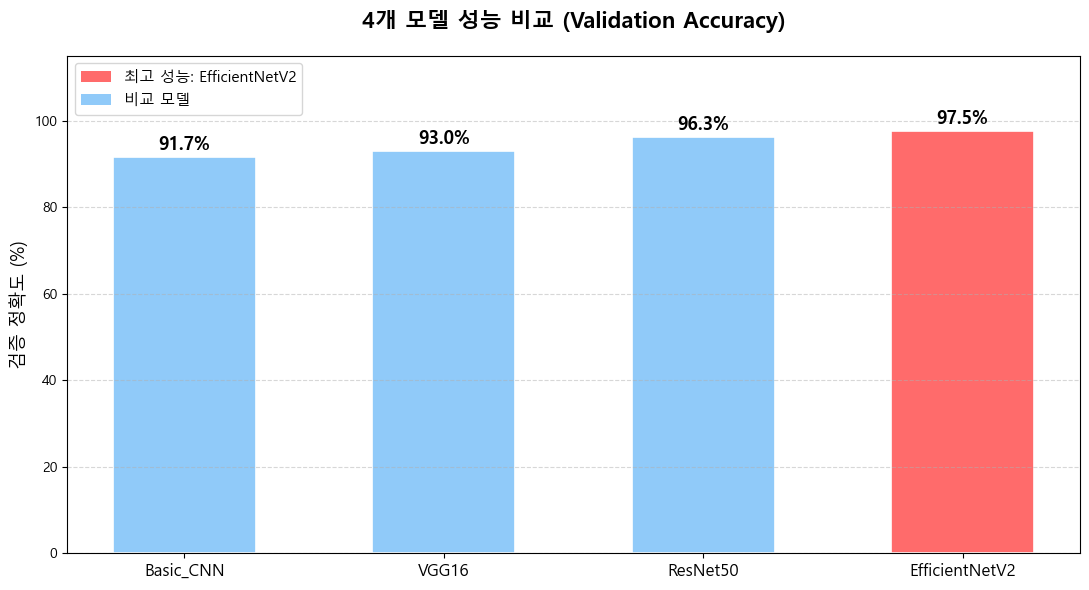

✅ 저장: results/01_model_comparison.png


In [20]:
model_labels = list(comparison_results.keys())
accuracies   = [v * 100 for v in comparison_results.values()]
best_idx     = model_labels.index(best_model_name)
bar_colors   = ['#FF6B6B' if n == best_model_name else '#90CAF9' for n in model_labels]
 
plt.figure(figsize=(11, 6))
bars = plt.bar(model_labels, accuracies, color=bar_colors,
               edgecolor='white', linewidth=1.2, width=0.55)
 
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f'{acc:.1f}%',
        ha='center', va='bottom', fontsize=13, fontweight='bold'
    )
 

 
plt.title('4개 모델 성능 비교 (Validation Accuracy)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('검증 정확도 (%)', fontsize=13)
plt.ylim([0, 115])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
 
legend_elems = [
    mpatches.Patch(facecolor='#FF6B6B', label=f'최고 성능: {best_model_name}'),
    mpatches.Patch(facecolor='#90CAF9', label='비교 모델')
]
plt.legend(handles=legend_elems, fontsize=11)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/01_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장: {RESULT_DIR}/01_model_comparison.png")

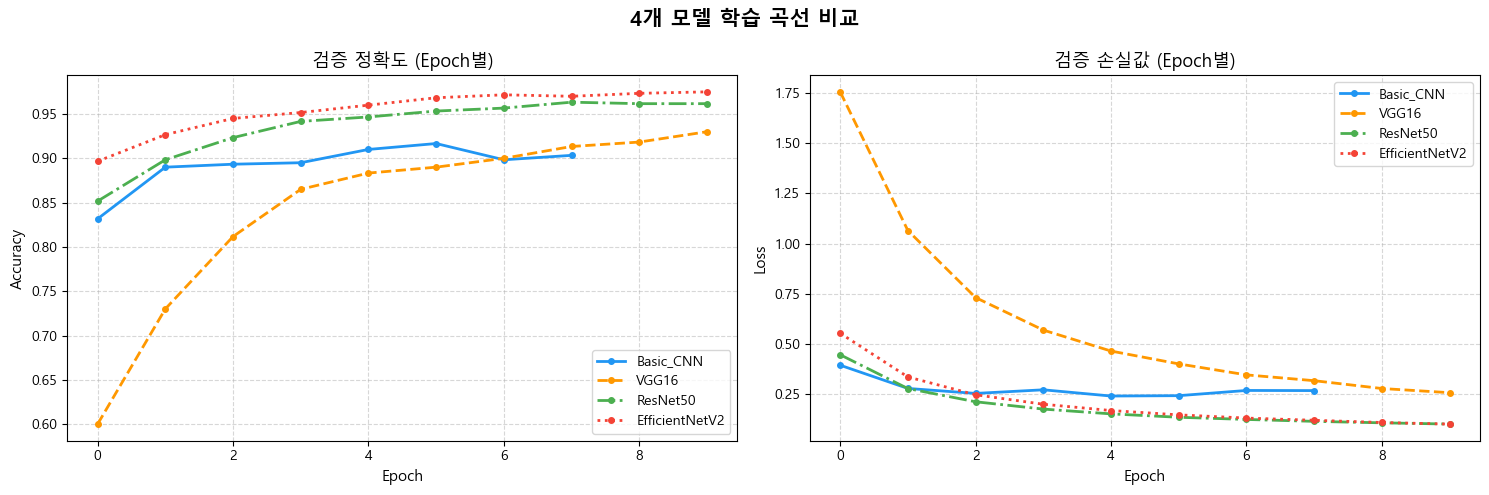

✅ 저장: results/02_comparison_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('4개 모델 학습 곡선 비교', fontsize=15, fontweight='bold')
 
line_styles  = ['-', '--', '-.', ':']
plot_colors  = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']
 
for i, (name, hist) in enumerate(comparison_histories.items()):
    kw = dict(linestyle=line_styles[i], color=plot_colors[i], linewidth=2, marker='o', markersize=4)
    axes[0].plot(hist['val_accuracy'], label=name, **kw)
    axes[1].plot(hist['val_loss'],     label=name, **kw)
 
for ax, title, ylabel in zip(axes,
    ['검증 정확도 (Epoch별)', '검증 손실값 (Epoch별)'],
    ['Accuracy', 'Loss']):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
 
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/02_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장: {RESULT_DIR}/02_comparison_curves.png")

In [21]:
print(f"\n🚀 {best_model_name} 전체 파이프라인 학습 시작!")
 
tf.keras.backend.clear_session()
 
# ── 증강 포함 ImageDataGenerator ────────────────────────────
# (이미 224×224이므로 target_size에서 별도 resize 없이 로드)
train_datagen = ImageDataGenerator(
    rotation_range=20,           # 랜덤 ±20도 회전
    width_shift_range=0.1,       # 가로 10% 이동
    height_shift_range=0.1,      # 세로 10% 이동
    zoom_range=0.15,             # 15% 확대/축소
    horizontal_flip=True,        # 좌우 반전
    brightness_range=[0.8, 1.2], # 밝기 80~120% 조절
    fill_mode='nearest'          # 빈 공간 채우기
)
val_datagen = ImageDataGenerator()
 
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),  # 이미 224×224이므로 변환 없음
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
 
print(f"클래스 인덱스: {train_gen.class_indices}")


🚀 EfficientNetV2 전체 파이프라인 학습 시작!
Found 2400 images belonging to 3 classes.
Found 600 images belonging to 3 classes.
클래스 인덱스: {'bad_weld': 0, 'blowhole': 1, 'good': 2}


In [39]:
base_model = EfficientNetV2B0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False    # 1단계: 베이스 동결
 
final_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),           # 과적합 방지
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])
 
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
final_model.summary()
 
# ── 1단계 학습 (헤드만) ─────────────────────────────────────
print("\n=== 1단계 학습 (Feature Extraction) ===")
history_s1 = final_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{MODEL_DIR}/best_stage1.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=1)
    ],
    verbose=1
)
print(f"  1단계 완료: {len(history_s1.history['loss'])} 에폭")
 
# ── 2단계 Fine-Tuning (마지막 20층 해동) ────────────────────
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False    # 하위 층은 계속 고정
 
final_model.compile(
    optimizer=Adam(learning_rate=1e-5),    # Fine-Tuning은 낮은 lr 필수
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
 
print("\n=== 2단계 학습 (Fine-Tuning) ===")
history_s2 = final_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{MODEL_DIR}/best_model_final.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=1)
    ],
    verbose=1
)
print(f"  2단계 완료: {len(history_s2.history['loss'])} 에폭")
print(f"\n✅ 모델 저장: {MODEL_DIR}/best_model_final.keras")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,091,731 (23.24 MB)

 Trainable params: 172,419 (673.51 KB)

 Non-trainable params: 5,919,312 (22.58 MB)


=== 1단계 학습 (Feature Extraction) ===
Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.8009 - loss: 0.4834
Epoch 1: val_accuracy improved from None to 0.97000, saving model to model/best_stage1.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 85s 488ms/step - accuracy: 0.8867 - loss: 0.2951 - val_accuracy: 0.9700 - val_loss: 0.0737
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9550 - loss: 0.1141
Epoch 2: val_accuracy improved from 0.97000 to 0.98333, saving model to model/best_stage1.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 70s 464ms/step - accuracy: 0.9571 - loss: 0.1121 - val_accuracy: 0.9833 - val_loss: 0.0378
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.9608 - loss: 0.1143
Epoch 3: val_accuracy improved from 0.98333 to 0.98833, saving model to model/best_stage1.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 458ms/step - accuracy: 0.9658 - loss: 0.1081 - val_accuracy: 0.9883 - val_loss: 0.0378
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step 

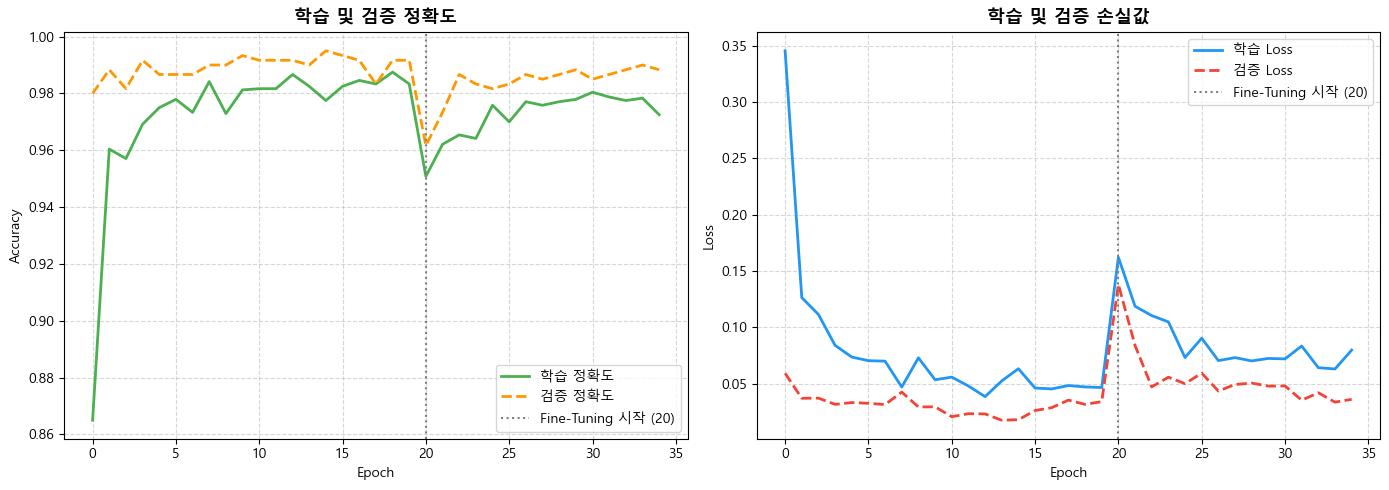

✅ 저장: results/03_learning_curves.png


In [23]:
def merge_history(h1, h2):
    """두 단계 히스토리 합치기"""
    return {k: h1.history[k] + h2.history[k] for k in h1.history}
 
hist_merged = merge_history(history_s1, history_s2)
s1_end = len(history_s1.history['loss'])
 
plt.figure(figsize=(14, 5))
 
plt.subplot(1, 2, 1)
plt.plot(hist_merged['accuracy'],     label='학습 정확도', color='#4CAF50', linewidth=2)
plt.plot(hist_merged['val_accuracy'], label='검증 정확도', color='#FF9800', linewidth=2, linestyle='--')
plt.axvline(x=s1_end, color='gray', linestyle=':', linewidth=1.5, label=f'Fine-Tuning 시작 ({s1_end})')
plt.title('학습 및 검증 정확도', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
 
plt.subplot(1, 2, 2)
plt.plot(hist_merged['loss'],     label='학습 Loss', color='#2196F3', linewidth=2)
plt.plot(hist_merged['val_loss'], label='검증 Loss', color='#F44336', linewidth=2, linestyle='--')
plt.axvline(x=s1_end, color='gray', linestyle=':', linewidth=1.5, label=f'Fine-Tuning 시작 ({s1_end})')
plt.title('학습 및 검증 손실값', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(fontsize=10); plt.grid(True, linestyle='--', alpha=0.5)
 
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/03_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장: {RESULT_DIR}/03_learning_curves.png")

In [24]:
val_gen.reset()
y_pred_probs   = final_model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true         = val_gen.classes
 
# 한글 클래스명 리스트 (인덱스 순서대로)
class_names_kor = [CLASS_KOR.get(c, c) for c in val_gen.class_indices.keys()]
idx_to_class    = {v: k for k, v in val_gen.class_indices.items()}
 
val_loss, val_acc = final_model.evaluate(val_gen, verbose=0)
print(f"\n최종 검증 정확도: {val_acc*100:.2f}%")
print(f"최종 검증 손실값: {val_loss:.4f}")
print("\n[최종 분류 리포트]")
print(classification_report(y_true, y_pred_classes,
                             target_names=class_names_kor, digits=4))

38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 315ms/step

최종 검증 정확도: 99.00%
최종 검증 손실값: 0.0336

[최종 분류 리포트]
              precision    recall  f1-score   support

        용접불량     0.9949    0.9850    0.9899       200
        블로우홀     0.9851    0.9900    0.9875       200
          양품     0.9900    0.9950    0.9925       200

    accuracy                         0.9900       600
   macro avg     0.9900    0.9900    0.9900       600
weighted avg     0.9900    0.9900    0.9900       600



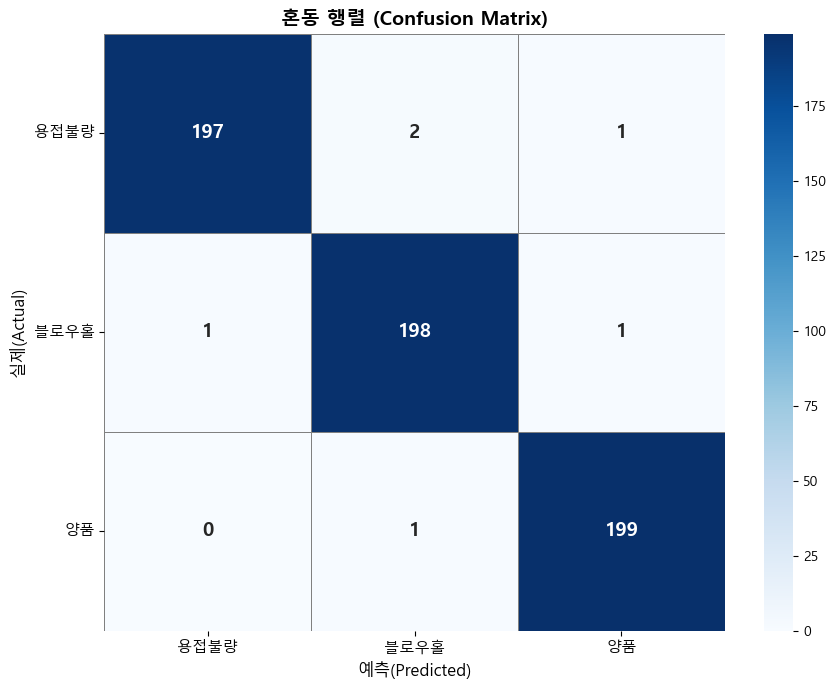

✅ 저장: results/04_confusion_matrix.png


In [27]:
cm = confusion_matrix(y_true, y_pred_classes)
 
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_kor,
            yticklabels=class_names_kor,
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('혼동 행렬 (Confusion Matrix)', fontsize=14, fontweight='bold')
plt.ylabel('실제(Actual)', fontsize=12)
plt.xlabel('예측(Predicted)', fontsize=12)
plt.xticks(fontsize=11); plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장: {RESULT_DIR}/04_confusion_matrix.png")

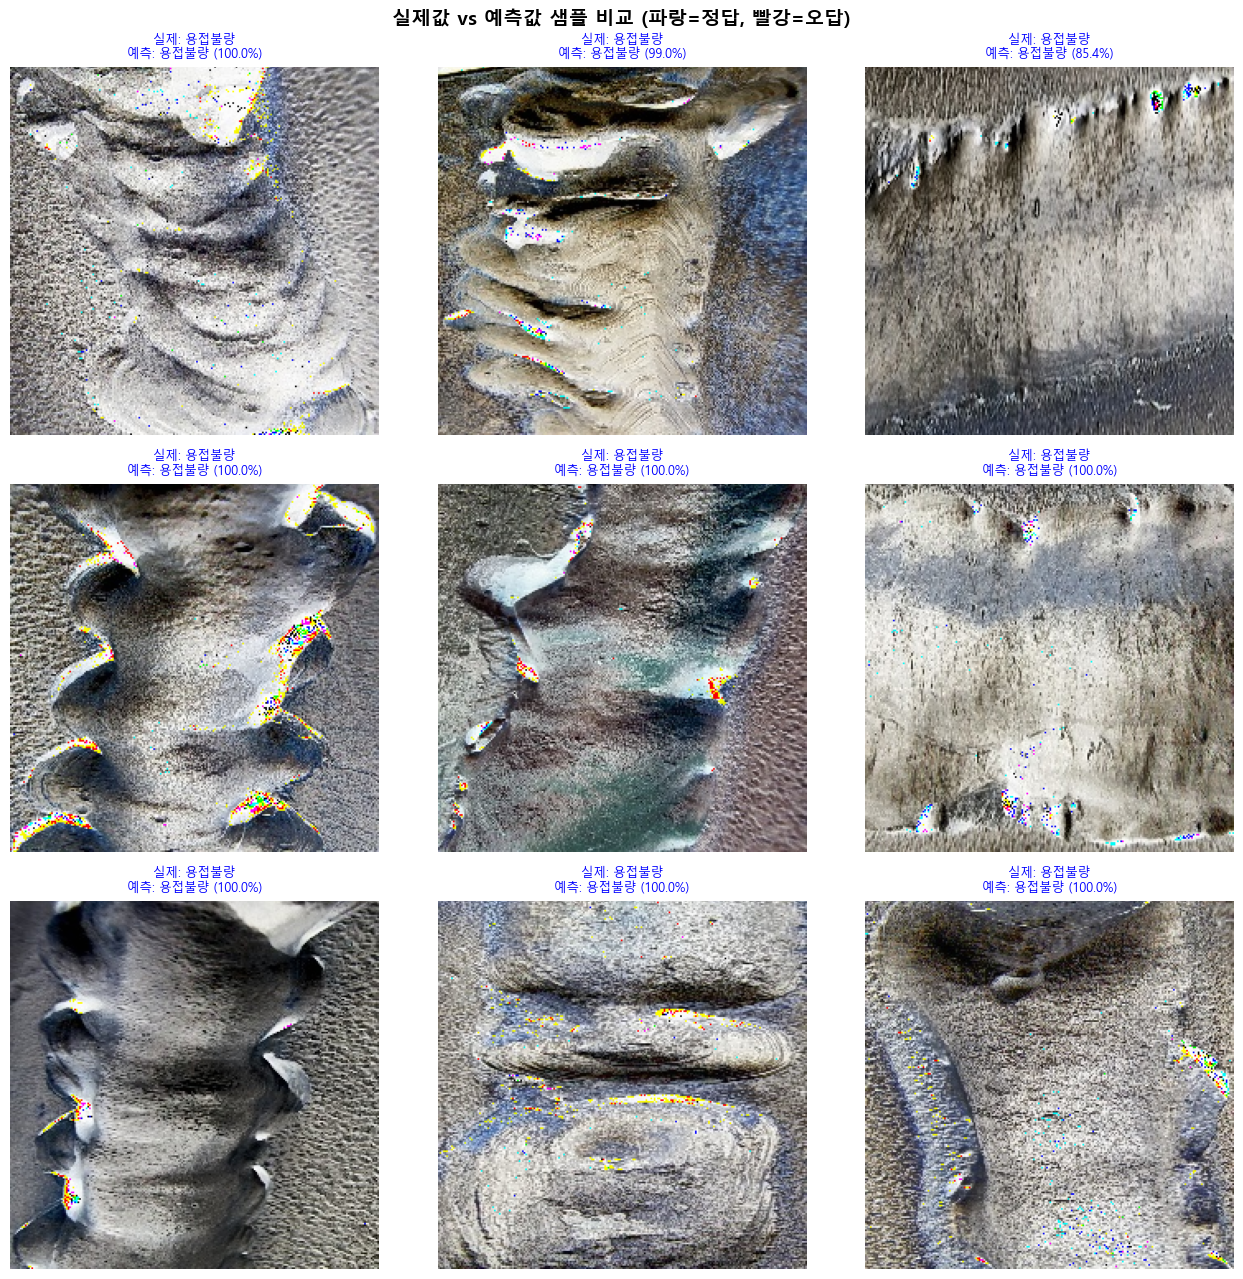

✅ 저장: results/05_sample_comparison.png


In [35]:

plt.figure(figsize=(13, 13))
plt.suptitle('실제값 vs 예측값 샘플 비교 (파랑=정답, 빨강=오답)',
             fontsize=14, fontweight='bold')
 
val_gen.reset()
for images, labels in val_gen:
    preds = final_model.predict(images, verbose=0)
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        # 이미 정규화된 이미지를 0~255로 복원해서 표시
        img_show = (images[i] * 255).astype("uint8")
        plt.imshow(img_show)
        actual = class_names_kor[np.argmax(labels[i])]
        pred   = class_names_kor[np.argmax(preds[i])]
        conf   = np.max(preds[i]) * 100
        color  = 'blue' if actual == pred else 'red'
        plt.title(f"실제: {actual}\n예측: {pred} ({conf:.1f}%)",
                  color=color, fontsize=9)
        plt.axis('off')
    break
 
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/05_sample_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장: {RESULT_DIR}/05_sample_comparison.png")

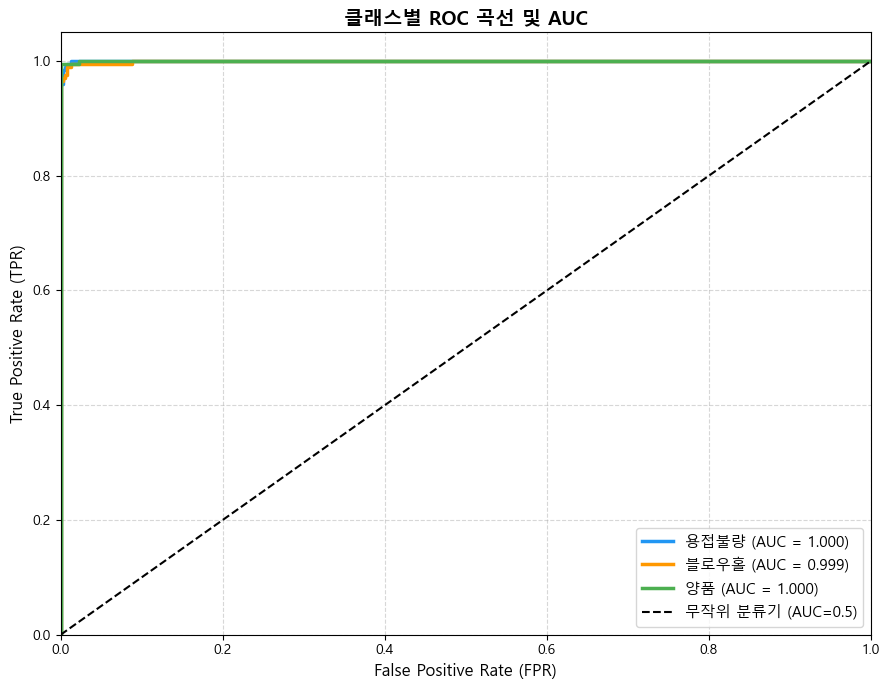

✅ 저장: results/06_roc_curve.png


In [43]:
# OVR(One-vs-Rest): 각 클래스를 나머지 전체와 비교하여 AUC 계산
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
colors_roc = ['#2196F3', '#FF9800', '#4CAF50']
 
plt.figure(figsize=(9, 7))
for i, (color, cls_kor) in enumerate(zip(colors_roc, class_names_kor)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{cls_kor} (AUC = {roc_auc:.3f})')
 
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='무작위 분류기 (AUC=0.5)')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('클래스별 ROC 곡선 및 AUC', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/06_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장: {RESULT_DIR}/06_roc_curve.png")

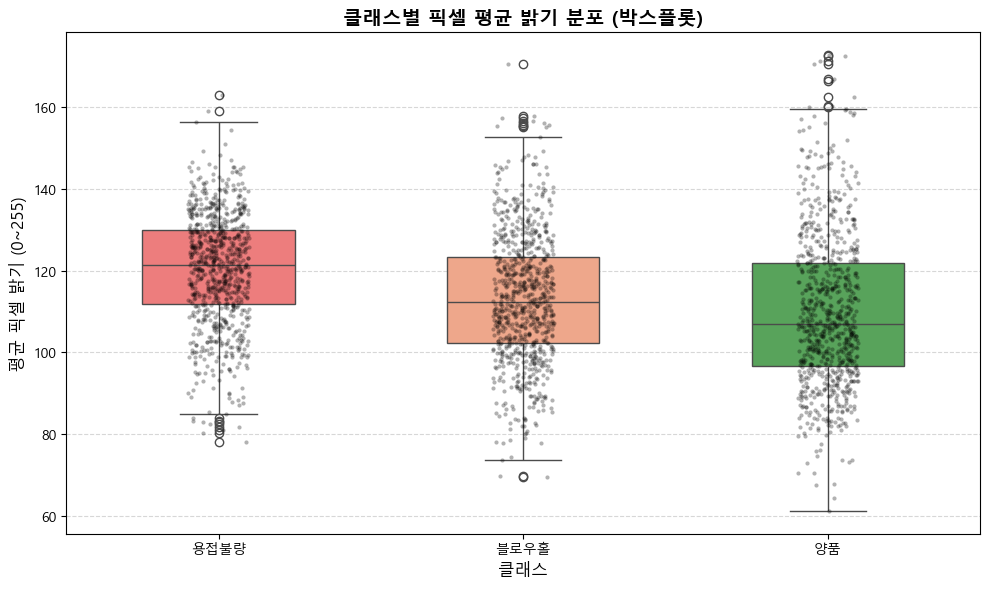

✅ 저장: results/07_brightness_boxplot.png

=== 클래스별 밝기 통계 ===
      count    mean    std    min     25%     50%     75%     max
클래스                                                              
블로우홀  800.0  113.20  15.64  69.54  102.36  112.28  123.42  170.53
양품    800.0  110.09  18.91  61.23   96.53  106.96  121.96  172.70
용접불량  800.0  120.36  13.65  77.98  111.71  121.41  129.99  162.93


In [42]:
brightness_data = []
 
for cls in val_gen.class_indices.keys():
    cls_path  = os.path.join(TRAIN_DIR, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for fname in img_files:
        # 그레이스케일로 로드 (밝기 분석용)
        img = cv2.imread(os.path.join(cls_path, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            # 이미 224×224이므로 resize 불필요
            brightness_data.append({
                '클래스':   CLASS_KOR.get(cls, cls),
                '평균 밝기': float(np.mean(img))
            })
 
brightness_df = pd.DataFrame(brightness_data)
 
plt.figure(figsize=(10, 6))
palette = {'용접불량': '#FF6B6B', '블로우홀': '#FFA07A', '양품': '#4CAF50'}
sns.boxplot(x='클래스', y='평균 밝기', data=brightness_df,
            palette=palette, width=0.5)
sns.stripplot(x='클래스', y='평균 밝기', data=brightness_df,
              color='black', alpha=0.3, size=3, jitter=True)
plt.title('클래스별 픽셀 평균 밝기 분포 (박스플롯)', fontsize=14, fontweight='bold')
plt.xlabel('클래스', fontsize=12)
plt.ylabel('평균 픽셀 밝기 (0~255)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/07_brightness_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"✅ 저장: {RESULT_DIR}/07_brightness_boxplot.png")
print("\n=== 클래스별 밝기 통계 ===")
print(brightness_df.groupby('클래스')['평균 밝기'].describe().round(2))


t-SNE 특징 벡터 추출 중... (로컬 CPU 기준 3~6분 소요)
특징 벡터 형태: (150, 1280)


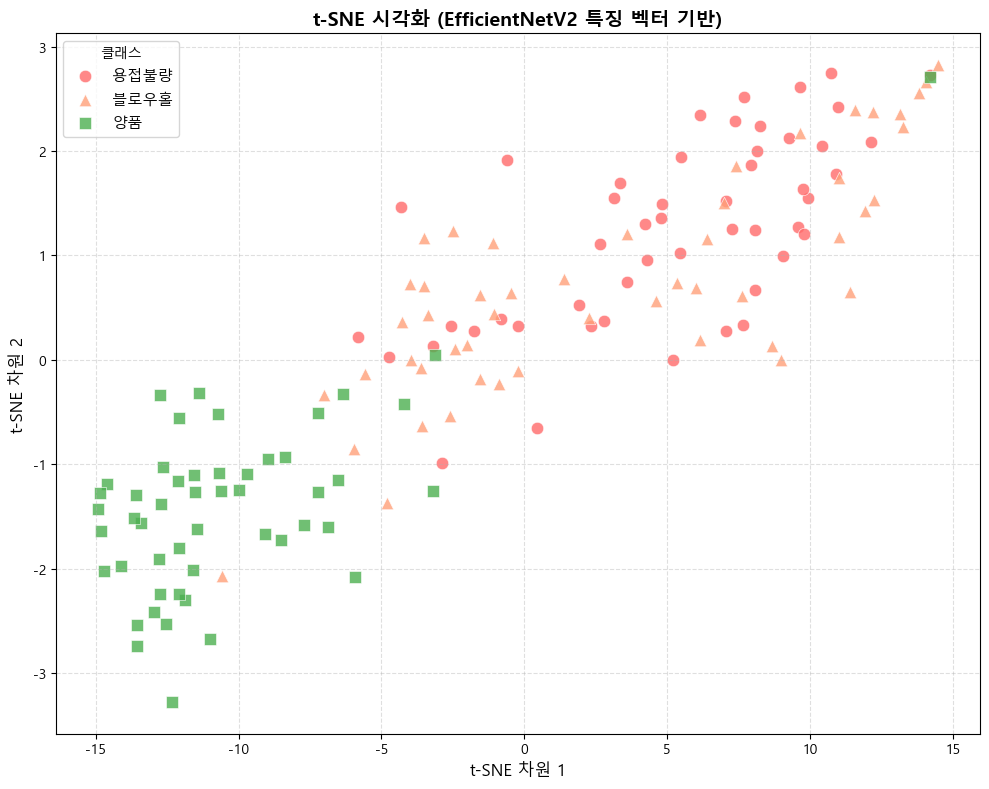

✅ 저장: results/08_tsne.png


In [44]:
# ✅ 모델의 GlobalAveragePooling 출력(특징 벡터)을 추출 후 t-SNE
print("\nt-SNE 특징 벡터 추출 중... (로컬 CPU 기준 3~6분 소요)")
 
# ✅ 새 Input 레이어로 직접 연결하는 방식
inp = tf.keras.Input(shape=(224, 224, 3))
x   = final_model.layers[0](inp)   # EfficientNetV2B0
x   = final_model.layers[1](x)     # GlobalAveragePooling2D ← 특징벡터

feat_extractor = tf.keras.Model(inputs=inp, outputs=x)

features_list = []
labels_list   = []

for cls in val_gen.class_indices.keys():
    cls_path  = os.path.join(TRAIN_DIR, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for fname in img_files[:50]:
        img_bgr = cv2.imread(os.path.join(cls_path, fname))
        if img_bgr is None:
            continue
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_norm = img_rgb.astype(np.float32) / 255.0
        img_arr  = np.expand_dims(img_norm, axis=0)

        feat = feat_extractor.predict(img_arr, verbose=0)
        features_list.append(feat[0])
        labels_list.append(CLASS_KOR.get(cls, cls))
 
features_array = np.array(features_list)
print(f"특징 벡터 형태: {features_array.shape}")
 
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result = tsne.fit_transform(features_array)
 
plt.figure(figsize=(10, 8))
color_map  = {'용접불량': '#FF6B6B', '블로우홀': '#FFA07A', '양품': '#4CAF50'}
marker_map = {'용접불량': 'o', '블로우홀': '^', '양품': 's'}
 
for cls_kor in ['용접불량', '블로우홀', '양품']:
    mask = np.array(labels_list) == cls_kor
    plt.scatter(
        tsne_result[mask, 0], tsne_result[mask, 1],
        label=cls_kor, c=color_map[cls_kor],
        marker=marker_map[cls_kor],
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )
 
plt.title('t-SNE 시각화 (EfficientNetV2 특징 벡터 기반)', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE 차원 1', fontsize=12)
plt.ylabel('t-SNE 차원 2', fontsize=12)
plt.legend(title='클래스', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/08_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장: {RESULT_DIR}/08_tsne.png")

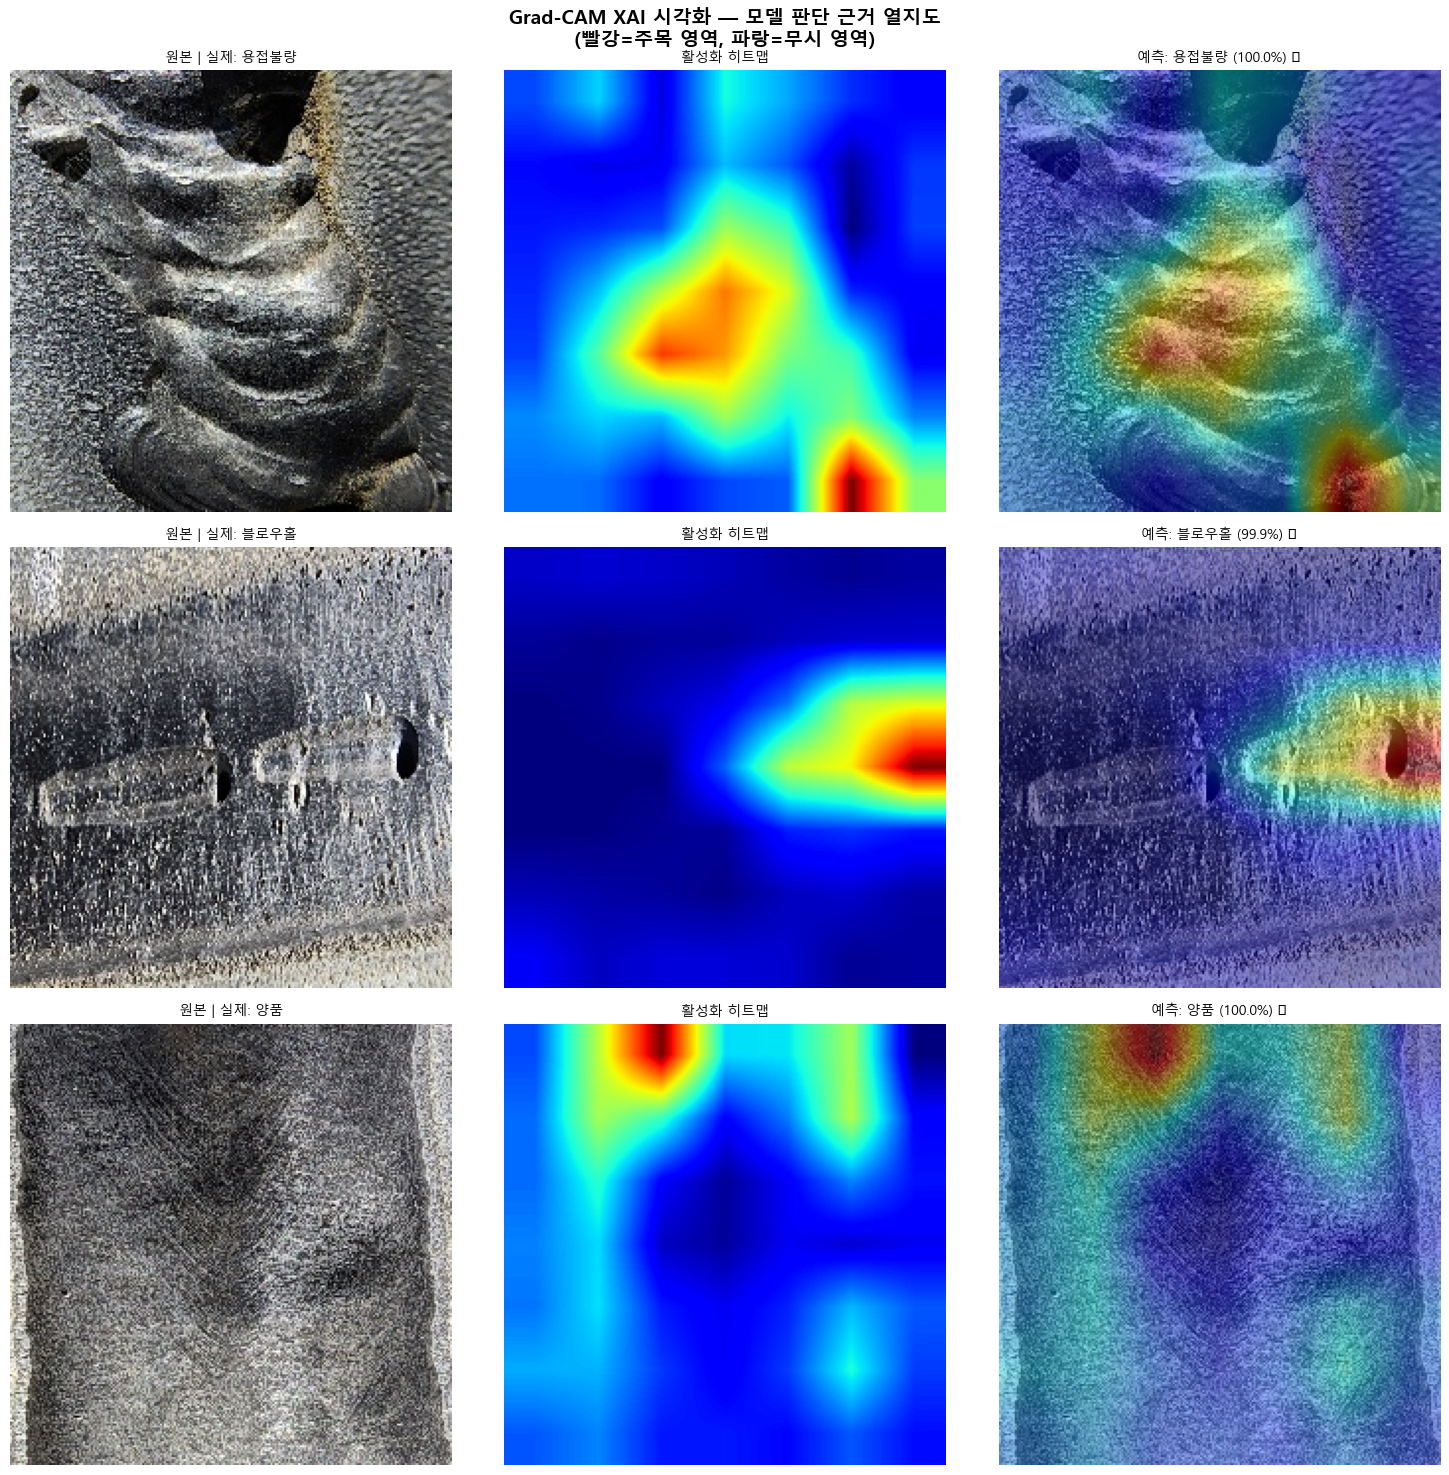

✅ 저장: results/09_gradcam.png


In [50]:
def get_gradcam(model, img_array):
    
    # ✅ EfficientNetV2 출력(7×7×1280)을 conv_out으로 직접 사용
    inp     = tf.keras.Input(shape=(224, 224, 3))
    eff_out = model.layers[0](inp)   # EfficientNetV2 → (None, 7, 7, 1280)
    x       = model.layers[1](eff_out)  # GAP
    x       = model.layers[2](x)        # Dense 128
    x       = model.layers[3](x)        # Dropout
    x       = model.layers[4](x)        # Dense 64
    x       = model.layers[5](x)        # Dropout
    out     = model.layers[6](x)        # Dense 3

    grad_model = tf.keras.Model(inputs=inp, outputs=[eff_out, out])

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        tape.watch(inputs)
        conv_out, preds = grad_model(inputs)
        pred_idx = tf.argmax(preds[0])
        loss     = preds[:, pred_idx]

    grads        = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = tf.squeeze(conv_out[0] @ pooled_grads[..., tf.newaxis]).numpy()
    heatmap      = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    return heatmap, int(pred_idx.numpy()), preds[0].numpy()
 
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Grad-CAM XAI 시각화 — 모델 판단 근거 열지도\n(빨강=주목 영역, 파랑=무시 영역)',
             fontsize=14, fontweight='bold')
 
for row, cls in enumerate(val_gen.class_indices.keys()):
    cls_path  = os.path.join(VAL_DIR, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # ✅ 정분류 샘플 찾을 때까지 순회
    found = False
    for img_file in img_files:
        img_path = os.path.join(cls_path, img_file)
        img_bgr  = cv2.imread(img_path)
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_norm = img_rgb.astype(np.float32)
        img_arr  = np.expand_dims(img_norm, axis=0)

        try:
            heatmap, pred_idx, probs = get_gradcam(final_model, img_arr)
            pred_kor = CLASS_KOR.get(idx_to_class[pred_idx], idx_to_class[pred_idx])
            true_kor = CLASS_KOR.get(cls, cls)

            # ✅ 정분류 샘플만 사용
            if pred_kor == true_kor:
                found = True
                break
        except:
            continue

    if not found:
        print(f"[{cls}] 정분류 샘플 없음")
        continue

    # 이하 시각화 코드 동일
    heatmap_res = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_col = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    heatmap_col = cv2.cvtColor(heatmap_col, cv2.COLOR_BGR2RGB)
    overlay     = cv2.addWeighted(img_rgb, 0.6, heatmap_col, 0.4, 0)

    correct = '✅'  # 이미 정분류만 필터링했으므로

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f'원본 | 실제: {true_kor}', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap_res, cmap='jet')
    axes[row, 1].set_title('활성화 히트맵', fontsize=10)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(
        f'예측: {pred_kor} ({probs[pred_idx]*100:.1f}%) {correct}', fontsize=10)
    axes[row, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/09_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장: {RESULT_DIR}/09_gradcam.png")

In [46]:
class_info = {
    'class_indices': val_gen.class_indices,
    'class_kor':     CLASS_KOR,
    'img_size':      IMG_SIZE,
    'best_model':    'EfficientNetV2B0',
    'val_accuracy':  float(val_acc)
}
with open('class_info.json', 'w', encoding='utf-8') as f:
    json.dump(class_info, f, ensure_ascii=False, indent=2)
 
print("\n" + "="*55)
print("🎉 전체 파이프라인 완료!")
print("="*55)
print("\n📊 모델 비교 결과:")
for name, acc in comparison_results.items():
    star = " ⭐" if name == best_model_name else ""
    print(f"  {name:20s}: {acc*100:.2f}%{star}")
 
print(f"\n🏆 최종 모델  : {best_model_name}")
print(f"✅ 검증 정확도: {val_acc*100:.2f}%")
 
print(f"\n📁 저장된 파일:")
saved_files = {
    f'{RESULT_DIR}/01_model_comparison.png':   '4모델 비교 막대그래프',
    f'{RESULT_DIR}/02_comparison_curves.png':  '학습 곡선 비교',
    f'{RESULT_DIR}/03_learning_curves.png':    '최종 모델 학습 곡선',
    f'{RESULT_DIR}/04_confusion_matrix.png':   'Confusion Matrix',
    f'{RESULT_DIR}/05_sample_comparison.png':  '실제 vs 예측 샘플',
    f'{RESULT_DIR}/06_roc_curve.png':          'ROC AUC 곡선',
    f'{RESULT_DIR}/07_brightness_boxplot.png': '픽셀 밝기 분포',
    f'{RESULT_DIR}/08_tsne.png':               't-SNE 시각화',
    f'{RESULT_DIR}/09_gradcam.png':            'Grad-CAM XAI',
    f'{MODEL_DIR}/best_model_final.keras':     'Streamlit용 최종 모델',
    'class_info.json':                         '클래스 정보 (Streamlit용)',
}
for path, desc in saved_files.items():
    exist = '✅' if os.path.exists(path) else '❌'
    print(f"  {exist} {path:45s} ← {desc}")
 
print("\n▶ 다음 단계: streamlit run app.py")


🎉 전체 파이프라인 완료!

📊 모델 비교 결과:
  Basic_CNN           : 91.67%
  VGG16               : 93.00%
  ResNet50            : 96.33%
  EfficientNetV2      : 97.50% ⭐

🏆 최종 모델  : EfficientNetV2
✅ 검증 정확도: 99.00%

📁 저장된 파일:
  ✅ results/01_model_comparison.png               ← 4모델 비교 막대그래프
  ✅ results/02_comparison_curves.png              ← 학습 곡선 비교
  ✅ results/03_learning_curves.png                ← 최종 모델 학습 곡선
  ✅ results/04_confusion_matrix.png               ← Confusion Matrix
  ✅ results/05_sample_comparison.png              ← 실제 vs 예측 샘플
  ✅ results/06_roc_curve.png                      ← ROC AUC 곡선
  ✅ results/07_brightness_boxplot.png             ← 픽셀 밝기 분포
  ✅ results/08_tsne.png                           ← t-SNE 시각화
  ✅ results/09_gradcam.png                        ← Grad-CAM XAI
  ✅ model/best_model_final.keras                  ← Streamlit용 최종 모델
  ✅ class_info.json                               ← 클래스 정보 (Streamlit용)

▶ 다음 단계: streamlit run app.py
